## 02. Baseline Modeling & Discovery

In the previous notebook, we identified that High satisfaction scores are not translating into higher loyalty for premium travelers. To understand what drives this, I am establishing a **Baseline Random Forest Model**.

Unlike linear models, a Random Forest captures complex, non-linear relationships (e.g., *satisfaction might drop sharply only after a certain threshold*). While a Deep Learning model might squeeze out a few extra percentage points of accuracy, it operates as a "Black Box."

For this analysis, I need an algorithm that can balance accuracy with interpretability. By feeding the model raw data without heavy engineering, I can disover **what matters most to the passenger** without losing the logic in a neural network.


### Load Libraries

In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

### Load and Inspect Data

In [16]:
# Load Data
df = pd.read_csv("../datasets/processed/cleaned_data.csv")
display(df.head())

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,type
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,4,3,4,4,5,5,25,18.0,neutral or dissatisfied,train
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,5,3,1,4,1,1,6.0,neutral or dissatisfied,train
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,4,3,4,4,4,5,0,0.0,satisfied,train
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,5,3,1,4,2,11,9.0,neutral or dissatisfied,train
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,4,4,3,3,3,0,0.0,satisfied,train


### Encode Categorical Data

In [17]:
df_train = df.copy()
df_train['label'] = df_train['satisfaction'].apply(lambda x:1 if x == 'satisfied' else 0)

encode_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
df_encoded = pd.get_dummies(df[encode_cols], columns=encode_cols, dtype=int)

df_train = pd.concat([df_train, df_encoded], axis=1)

display(df_encoded.head())

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,0,1,1,0,0,1,0,0,1
1,0,1,0,1,1,0,1,0,0
2,1,0,1,0,1,0,1,0,0
3,1,0,1,0,1,0,1,0,0
4,0,1,1,0,1,0,1,0,0


In [18]:
# Drop unnecesaary columns
dropped_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']
df_train = df_train.drop(dropped_cols, axis=1)

In [19]:
# Create train dataset
X_train = y_train = df_train[df_train['type'] == 'train']
X_train = X_train.drop(['type', 'label'], axis=1)
y_train = y_train['label']

# Create test dataset
X_test = y_test = df_train[df_train['type'] == 'test']
X_test = X_test.drop(['type', 'label'], axis=1)
y_test = y_test['label']

In [20]:
# Create model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [21]:
# Evaluate model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.965
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14528
           1       0.97      0.95      0.96     11365

    accuracy                           0.97     25893
   macro avg       0.97      0.96      0.96     25893
weighted avg       0.97      0.97      0.97     25893



### Visualize Features

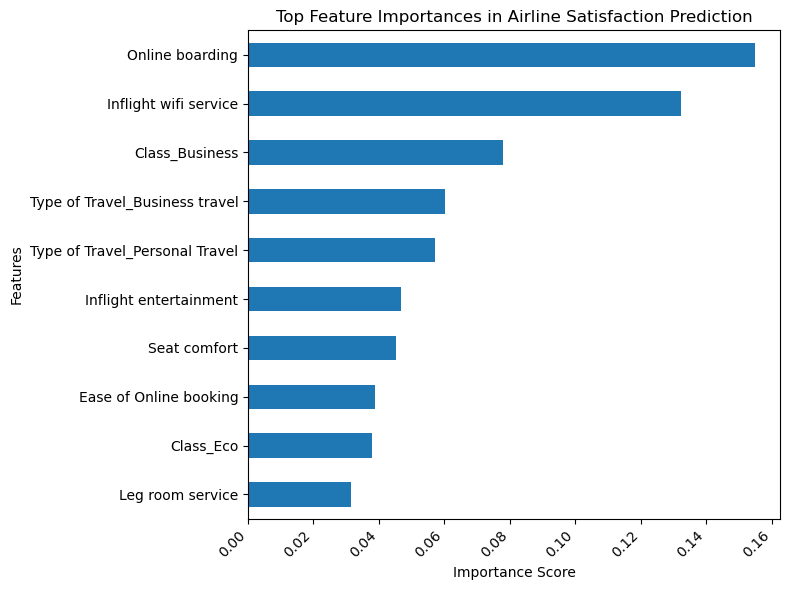

In [31]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

feature_names = X_train.columns
n = min(10, len(importances))

forest_importances = pd.Series(importances, index=feature_names)
forest_importances = forest_importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
forest_importances.head(n).plot.barh(ax=ax)
ax.set_title('Top Feature Importances in Airline Satisfaction Prediction')
ax.set_ylabel('Features')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.xticks(rotation=45, ha='right')
fig.tight_layout()

The Feature Importance plot reveals a clear outlier. `Online boarding` dominates the ranking (Importance > 0.16), significantly outperforming core physical attributes like `Seat comfort` and `Leg room`. It seems unusual for a pre-flight step to outweigh the in-flight experience. 

Is this sensitivity uniform across all passengers, or is it driven by a specific segment?

### Breakdown by Class

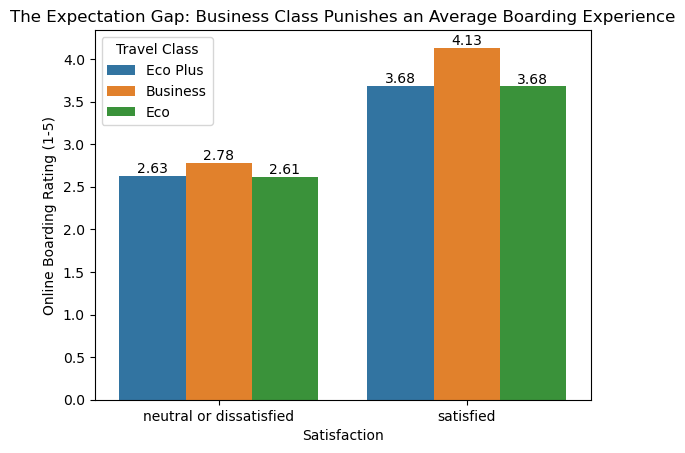

In [23]:
fig, ax = plt.subplots()
sns.barplot(data=df, y='Online boarding', x='satisfaction', hue='Class', ax=ax, errorbar=None)
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.bar_label(ax.containers[1], fmt='%.2f')
ax.bar_label(ax.containers[2], fmt='%.2f')

ax.set_title("The Expectation Gap: Business Class Punishes an Average Boarding Experience")
ax.set_ylabel("Online Boarding Rating (1-5)")
ax.set_xlabel("Satisfaction")
ax.legend(title='Travel Class')
plt.show()

The char confirms that the relationship between `Online boarding` and `satisfaction` is based on class. Average ratings (~2.6-3.0) for Economy still yield moderate satisfaction probabilities. Business ratings below ~4.0 correlate strongly with dissatisfaction.

To help the model isolate this high-value signal, I will move to [Notebook 03](03_feature_engineering.ipynb) to explicitly engineer a `Biz_Boarding_Interaction` feature, alongside other composite scores to test the "Digital vs. Physical" hypothesis.